In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns

In [3]:
df = pd.read_csv("concrete_data.csv")
df.head()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [5]:
df.isnull().sum()

cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

In [6]:
# Identify numeric features from the dataset.
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns used for z-score normalization:", numeric_cols)

Numeric columns used for z-score normalization: ['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate ', 'age', 'concrete_compressive_strength']


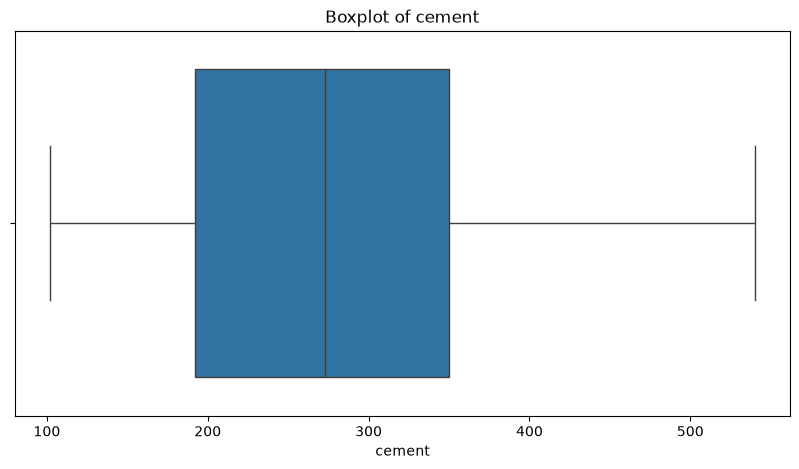

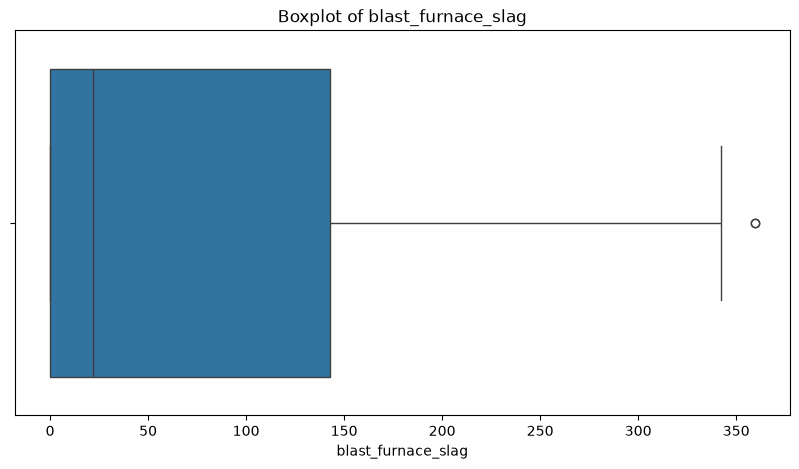

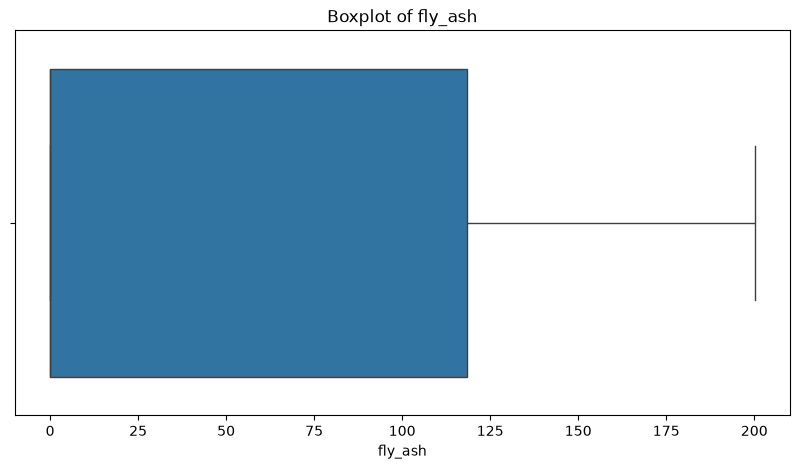

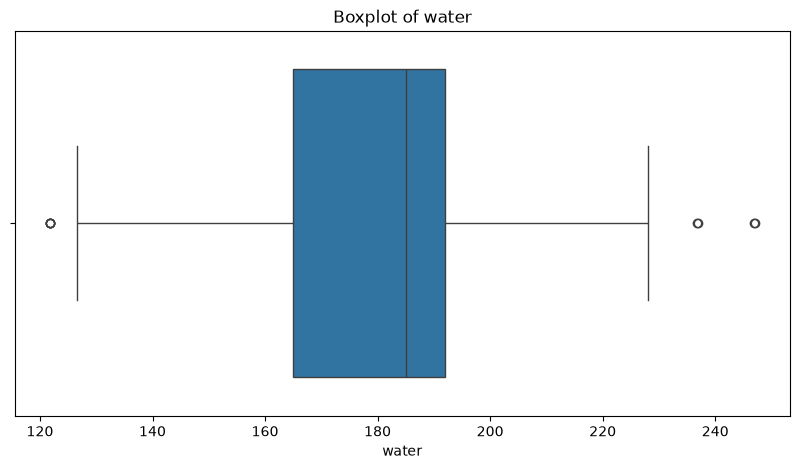

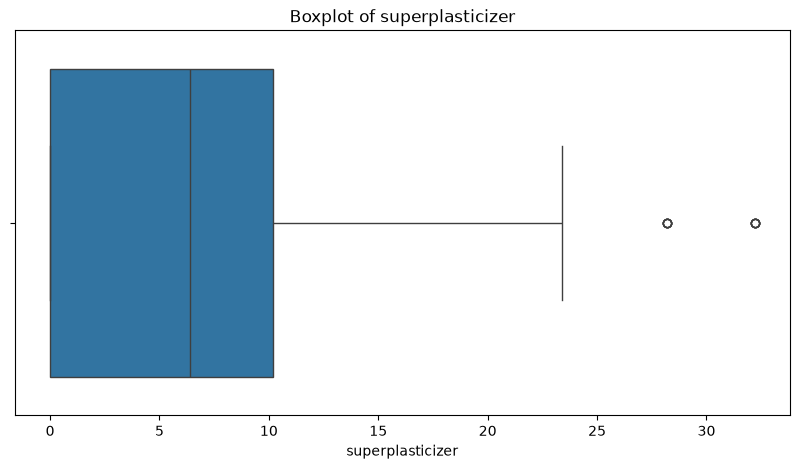

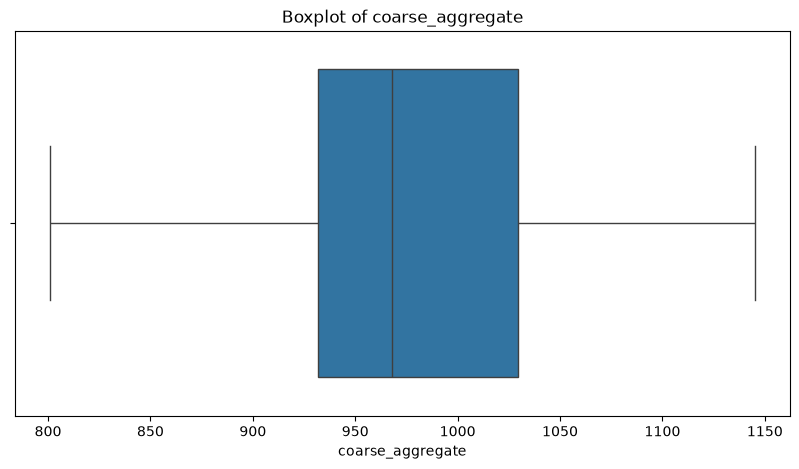

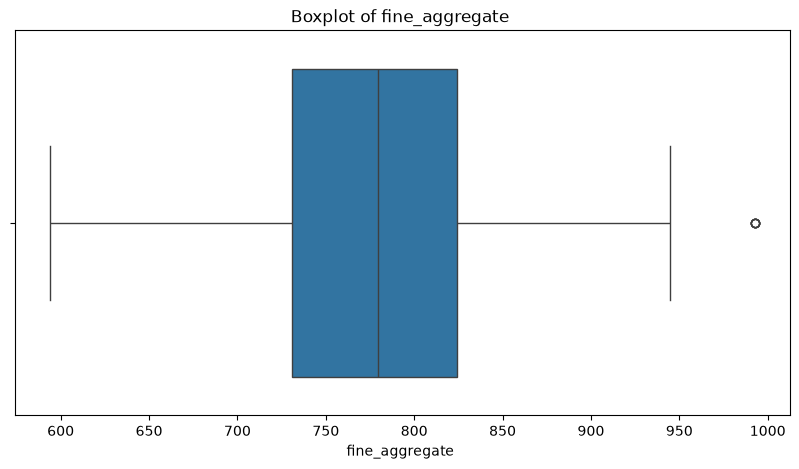

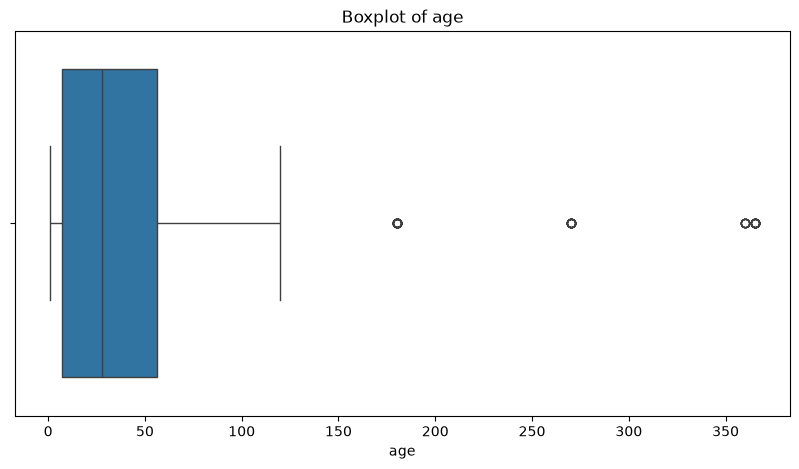

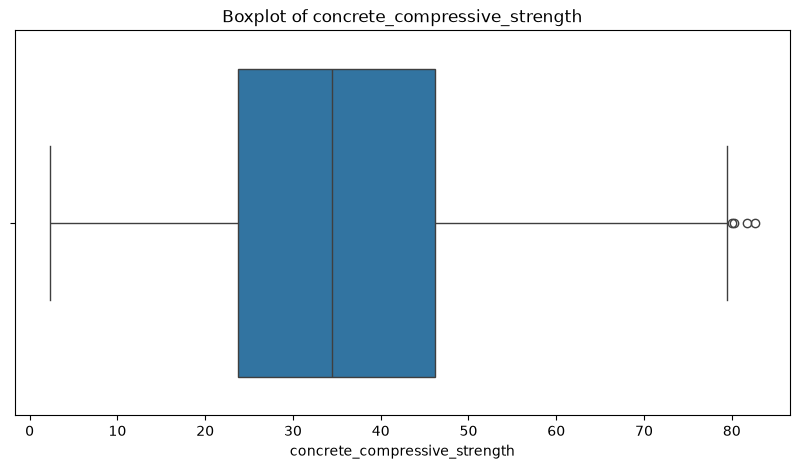

In [7]:
for col in numeric_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [8]:
def remove_outliers_iqr(df, cols, k=1.7):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - k * IQR
        upper_bound = Q3 + k * IQR
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

df_original_rows = len(df)

df = remove_outliers_iqr(df, numeric_cols)
df_cleaned_rows = len(df)
print(f"Original rows: {df_original_rows}, rows after outlier removal: {df_cleaned_rows}")

Original rows: 1030, rows after outlier removal: 953


In [9]:
print(df)

      cement  blast_furnace_slag  fly_ash  water  superplasticizer  \
0      540.0                 0.0      0.0  162.0               2.5   
1      540.0                 0.0      0.0  162.0               2.5   
5      266.0               114.0      0.0  228.0               0.0   
7      380.0                95.0      0.0  228.0               0.0   
8      266.0               114.0      0.0  228.0               0.0   
...      ...                 ...      ...    ...               ...   
1025   276.4               116.0     90.3  179.6               8.9   
1026   322.2                 0.0    115.6  196.0              10.4   
1027   148.5               139.4    108.6  192.7               6.1   
1028   159.1               186.7      0.0  175.6              11.3   
1029   260.9               100.5     78.3  200.6               8.6   

      coarse_aggregate  fine_aggregate   age  concrete_compressive_strength  
0               1040.0            676.0   28                          79.99  
1  

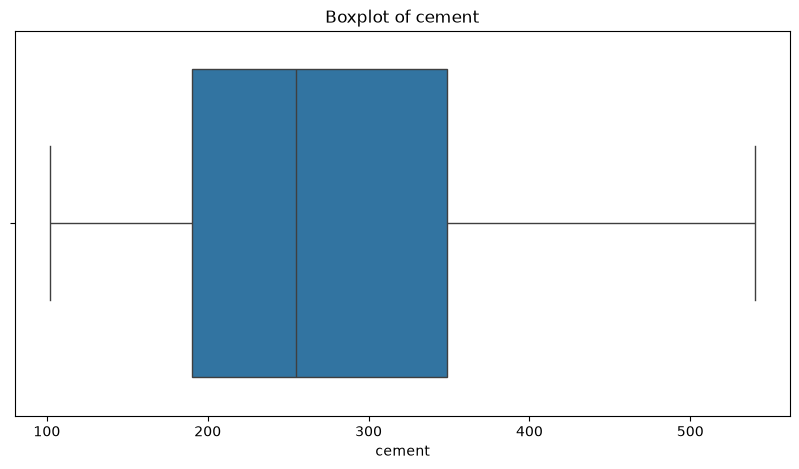

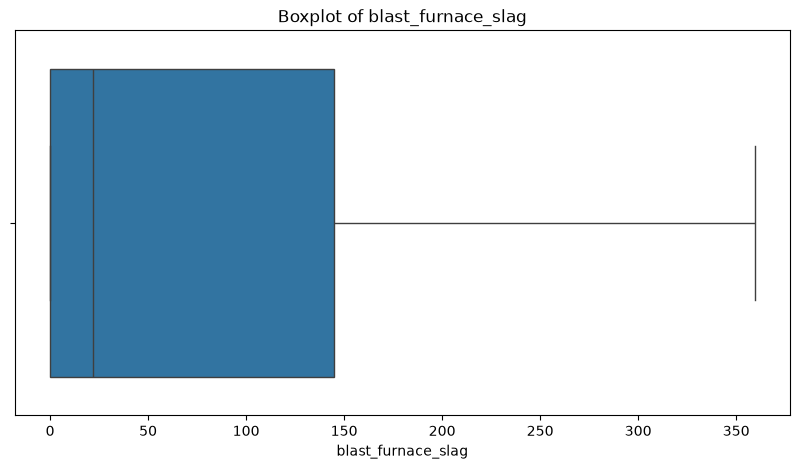

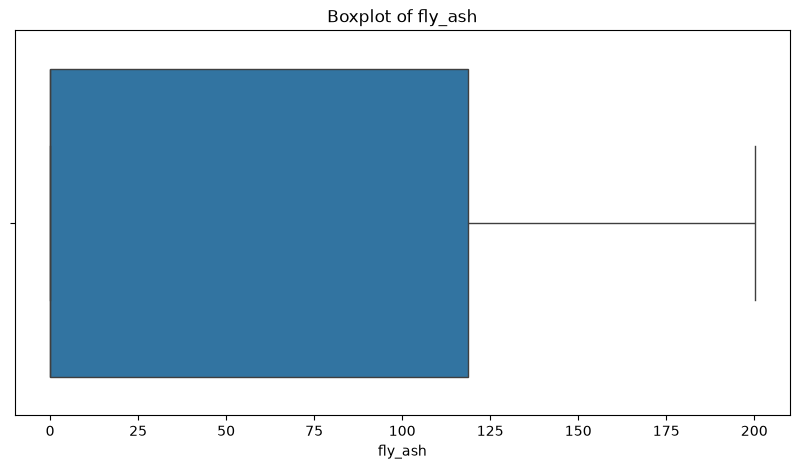

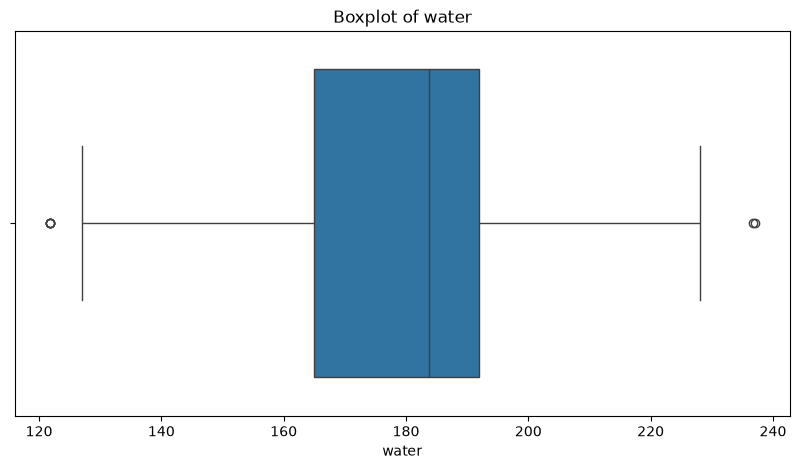

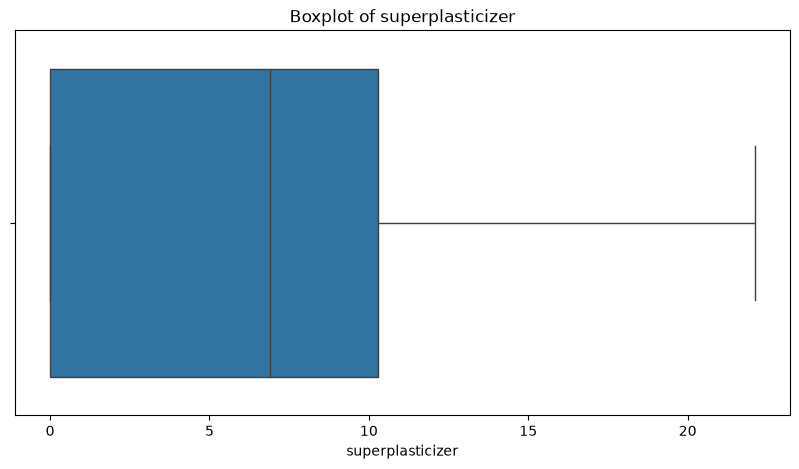

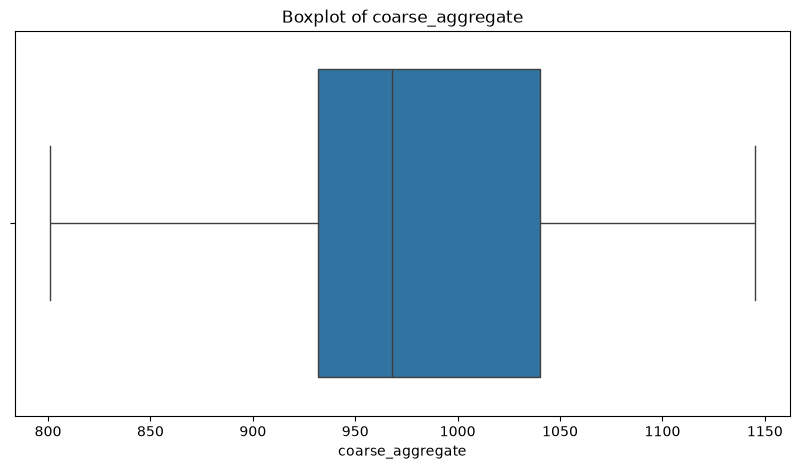

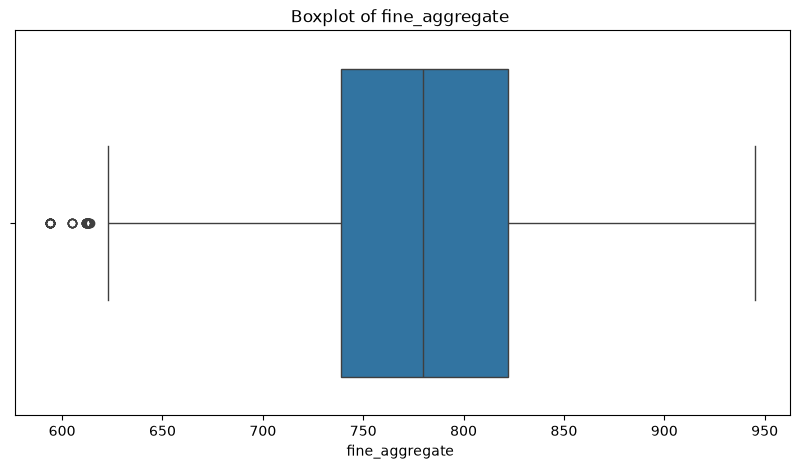

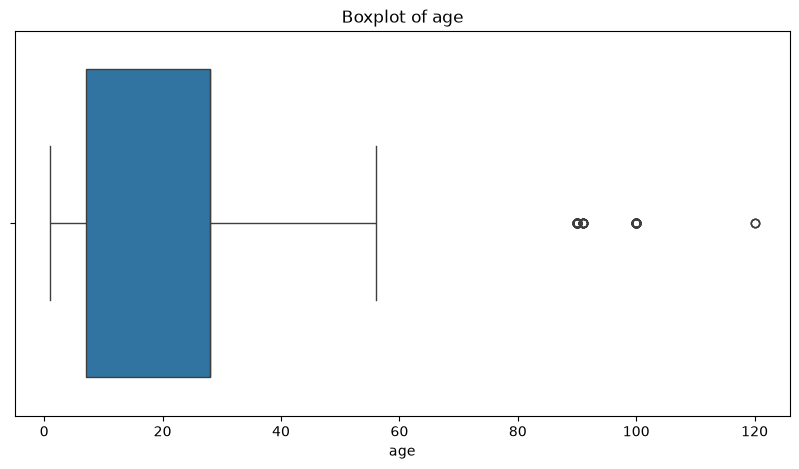

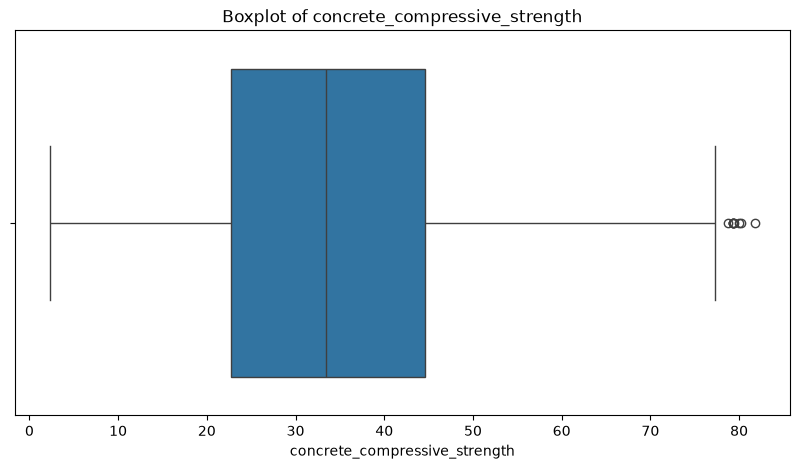

In [10]:
for col in numeric_cols:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [11]:
corr = df[numeric_cols].corr()

In [12]:
numeric_df = df[numeric_cols]

In [13]:
print(corr)

                                 cement  blast_furnace_slag   fly_ash  \
cement                         1.000000           -0.260462 -0.381508   
blast_furnace_slag            -0.260462            1.000000 -0.351193   
fly_ash                       -0.381508           -0.351193  1.000000   
water                         -0.079508            0.121791 -0.256337   
superplasticizer               0.031703            0.037585  0.449535   
coarse_aggregate              -0.096790           -0.291344 -0.033092   
fine_aggregate                -0.235070           -0.305088  0.065776   
age                           -0.036568           -0.038342  0.056471   
concrete_compressive_strength  0.479248            0.143835 -0.066297   

                                  water  superplasticizer  coarse_aggregate  \
cement                        -0.079508          0.031703         -0.096790   
blast_furnace_slag             0.121791          0.037585         -0.291344   
fly_ash                       -0

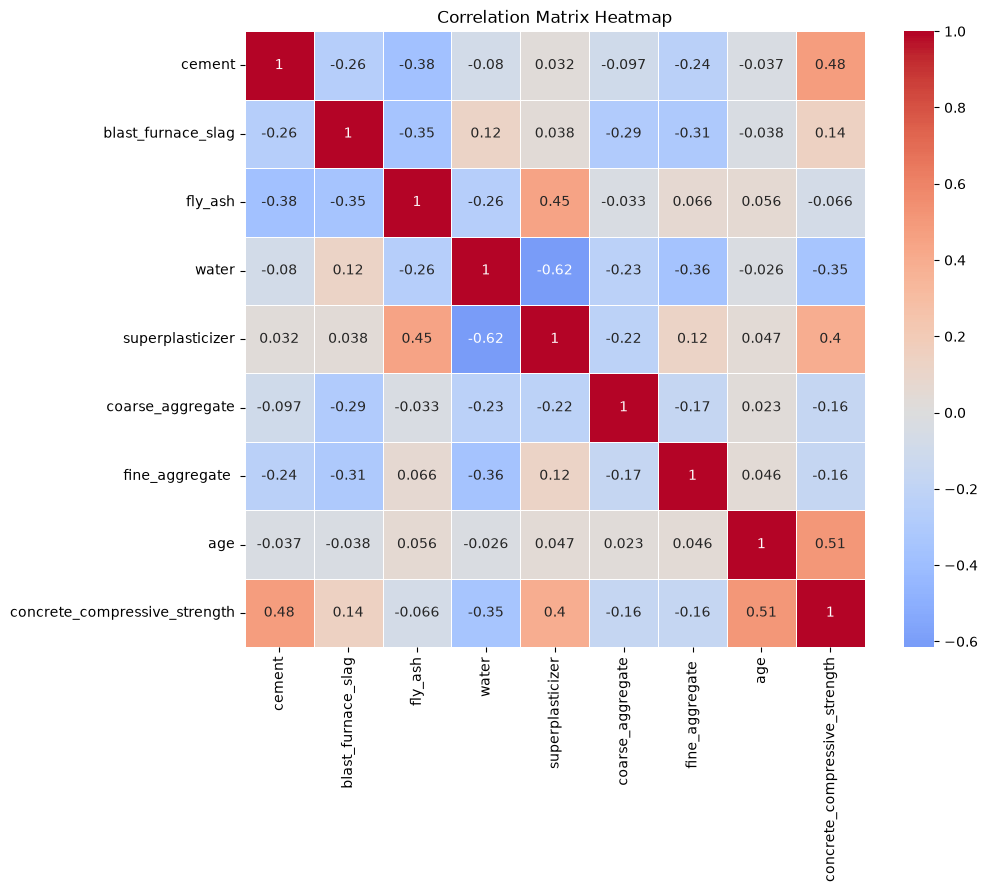

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

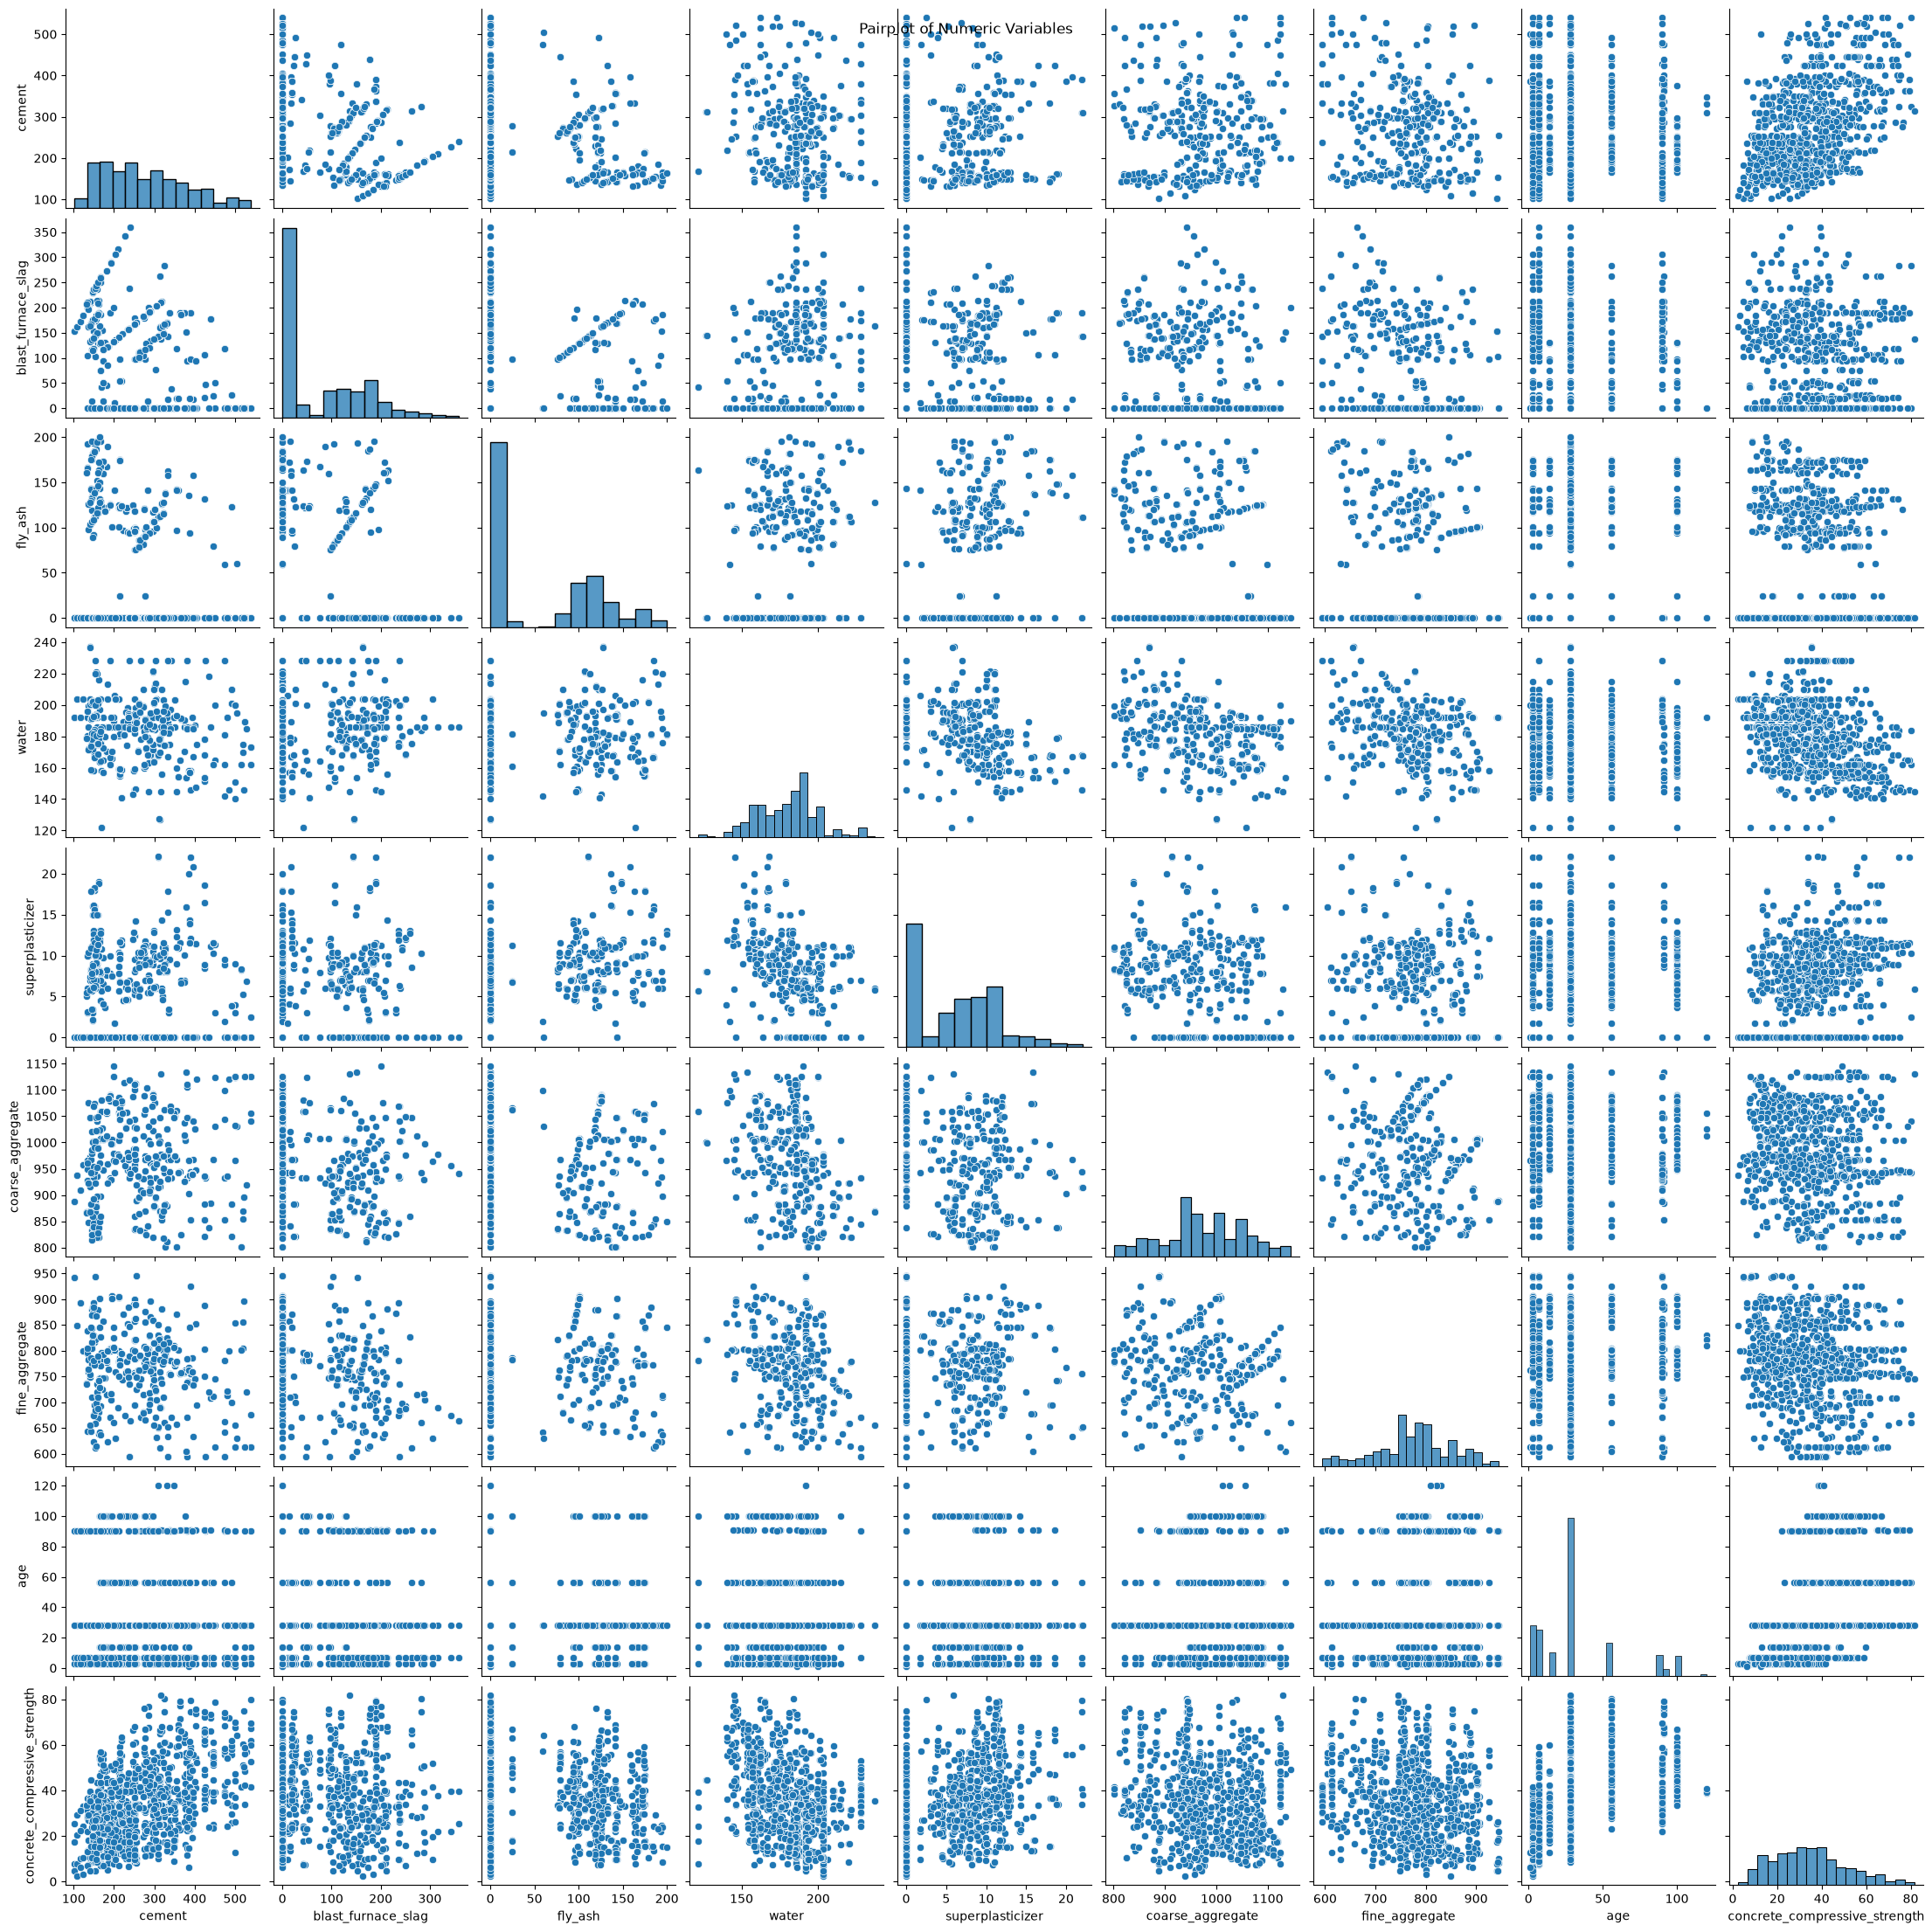

No strong correlations found at threshold 0.7. Lowering threshold to 0.5
    var1                           var2  abs_corr direction
0  water               superplasticizer  0.615216  negative
1    age  concrete_compressive_strength  0.512627  positive


In [15]:
pairplot = sns.pairplot(numeric_df)
pairplot.fig.suptitle('Pairplot of Numeric Variables')
plt.show()

# Strongest relationships
corr = numeric_df.corr()
corr_abs = corr.abs()

mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)
upper = corr_abs.where(mask)

pairs = upper.stack().reset_index()
pairs.columns = ["var1", "var2", "abs_corr"]

pairs = pairs.dropna()
pairs = pairs.sort_values(by="abs_corr", ascending=False)

threshold = 0.7
strong_pairs = pairs[pairs["abs_corr"] >= threshold].reset_index(drop=True)
if strong_pairs.empty:
    print(f"No strong correlations found at threshold {threshold}. Lowering threshold to 0.5")
    threshold = 0.5
    strong_pairs = pairs[pairs["abs_corr"] >= threshold].reset_index(drop=True)

strong_pairs["direction"] = np.where(
    strong_pairs.apply(lambda row: corr.loc[row["var1"], row["var2"]] >= 0, axis=1),
    "positive",
    "negative"
)

print(strong_pairs.head(20))

In [16]:
from sklearn.model_selection import train_test_split



In [17]:
# Predictor (must be 2D)
X = df.drop(columns=['concrete_compressive_strength'])
Y = df['concrete_compressive_strength']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size= 0.7, test_size=0.3, random_state=42)

In [18]:
print("Training set size:", X_train.shape[0])

Training set size: 667


In [19]:
print("Test set size:", X_test.shape[0])

Test set size: 286


In [20]:
from xgboost import XGBRegressor


In [21]:
import xgboost as xgb

In [22]:
dtrain = xgb.DMatrix(X_train, label=Y_train)
dtest  = xgb.DMatrix(X_test, label=Y_test)

In [23]:
params = {
    'objective': 'reg:squarederror',
    'colsample_bytree': 0.3,
    'learning_rate': 0.1,
    'max_depth': 5,
    'alpha': 10,
    #'n_estimators': 10
}

In [24]:
n=100
model = xgb.train(params = params, dtrain = dtrain, num_boost_round=n)

In [25]:
y_pred = model.predict(dtest)

In [26]:
print(y_pred)

[14.369444  44.4616    59.246143  38.64955   16.043955  15.1279
 48.989902  26.893223  31.105186  10.866106  30.61618   23.567617
 47.204266  41.352207  34.798157  56.832047  26.046713  46.912186
 68.33834   52.765945  32.212288  47.20938   29.346773  36.524338
 14.956324  26.14028   18.706959  20.202036  38.216377  13.346988
 16.975504  19.709845  26.15626   56.177     43.065197  27.818691
 30.980265   9.701733  38.975414  35.500717  36.591404  51.673847
 29.121181  52.881897  69.37309   42.393482  48.12917   33.10246
 42.856613  21.17476   53.25239   63.686497  46.900528  41.455357
 13.671522  60.997242  22.58451   34.275387  18.147058  32.4429
 41.765545  19.506155  34.302456  55.24048   43.080433  45.638912
 36.417564  51.000336  29.789156  47.389053  29.000292  57.574894
 52.30224   40.360947  12.578993  46.572716   9.986407  21.047314
 17.678741  21.456244  37.89767   32.969257  26.395546  20.248432
 28.643993  24.017265  50.11957   33.249485  40.736946  26.3431
 25.768976  56.56

In [27]:
y_pred = model.predict(dtest)

data = {"actual": Y_test, "predicted": y_pred}

pred_df = pd.DataFrame(data)
pred_df

,actual,predicted
249,13.82,14.369444
470,40.15,44.461601
754,69.66,59.246143
825,39.09,38.649551
557,17.24,16.043955
...,...,...
861,37.26,40.934696
514,74.36,65.546852
939,32.72,32.535561
455,51.26,46.938122


In [28]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
mse = mean_squared_error(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

In [29]:
print(r2)
print(mse)
print(mae)

0.8870725395194029
30.14696740926417
3.936154981426426


     actual  predicted
249   13.82  14.369444
470   40.15  44.461601
754   69.66  59.246143
825   39.09  38.649551
557   17.24  16.043955


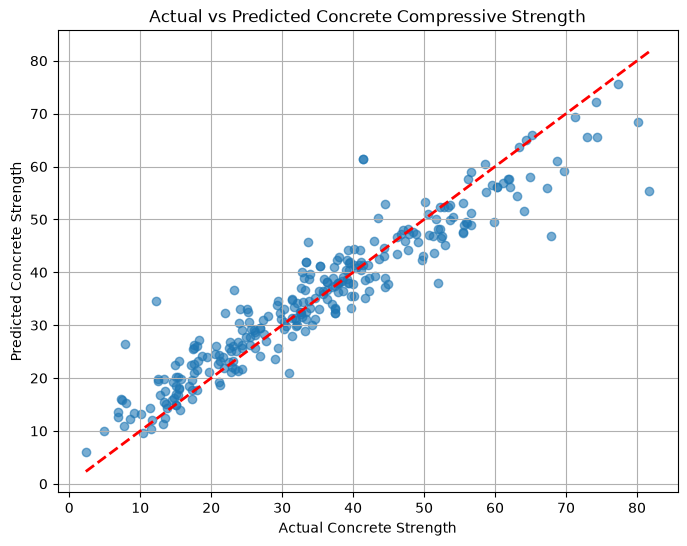

In [30]:
import matplotlib.pyplot as plt

print(pred_df.head())

plt.figure(figsize=(8, 6))
plt.scatter(Y_test, y_pred, alpha=0.6)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], '--', color='red', linewidth=2)
plt.xlabel('Actual Concrete Strength')
plt.ylabel('Predicted Concrete Strength')
plt.title('Actual vs Predicted Concrete Compressive Strength')
plt.grid(True)
plt.show()


In [31]:
from sklearn.model_selection import GridSearchCV

# Use the sklearn wrapper for XGBoost so we can tune hyperparameters with GridSearchCV.
xgb_reg = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'colsample_bytree': [0.3, 0.5, 0.7],
}

grid_search = GridSearchCV(
    estimator=xgb_reg,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1,
)

grid_search.fit(X_train, Y_train)

print('Best hyperparameters:', grid_search.best_params_)
print('Best R2 score (CV):', grid_search.best_score_)

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print('Test R2:', r2_score(Y_test, y_pred_tuned))
print('Test MSE:', mean_squared_error(Y_test, y_pred_tuned))
print('Test MAE:', mean_absolute_error(Y_test, y_pred_tuned))


Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best hyperparameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Best R2 score (CV): 0.9034432936094059
Test R2: 0.888574946115875
Test MSE: 29.745886905845904
Test MAE: 3.7000087173835383


                R2        MSE       MAE
Model                                  
Original  0.887073  30.146967  3.936155
Tuned     0.888575  29.745887  3.700009


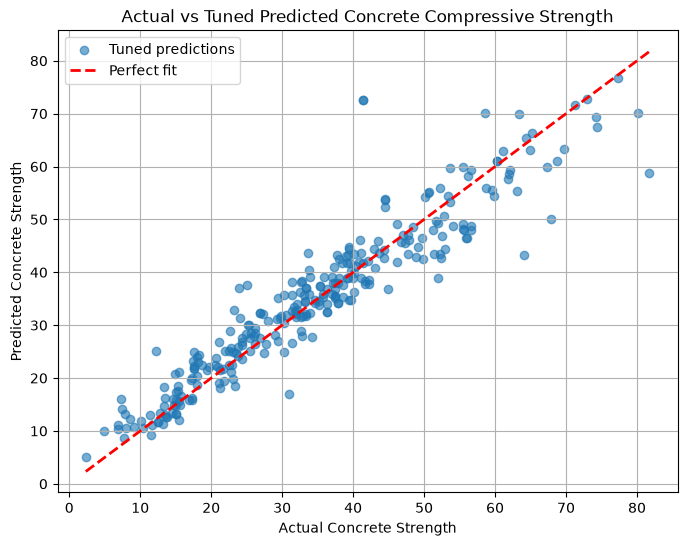

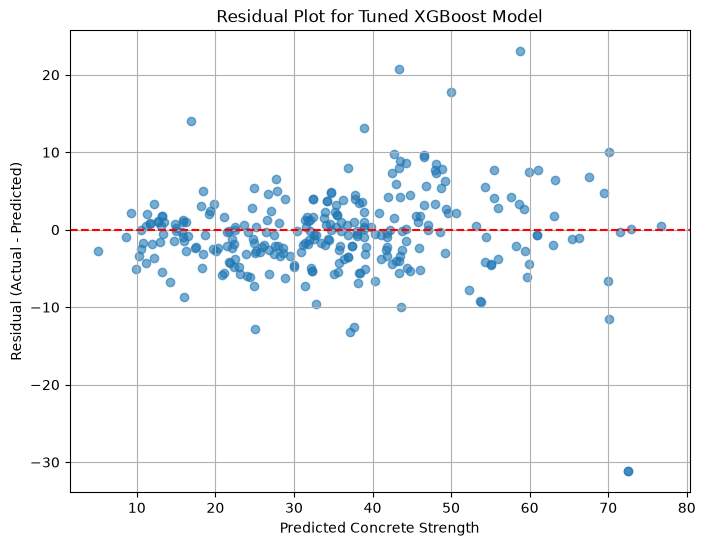

Top feature importances:
age                   0.286517
cement                0.207373
fly_ash               0.142389
water                 0.129619
superplasticizer      0.096471
blast_furnace_slag    0.075334
fine_aggregate        0.036313
coarse_aggregate      0.025984
dtype: float32


C:\Users\Admin\AppData\Local\Temp\ipykernel_9400\137990906.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


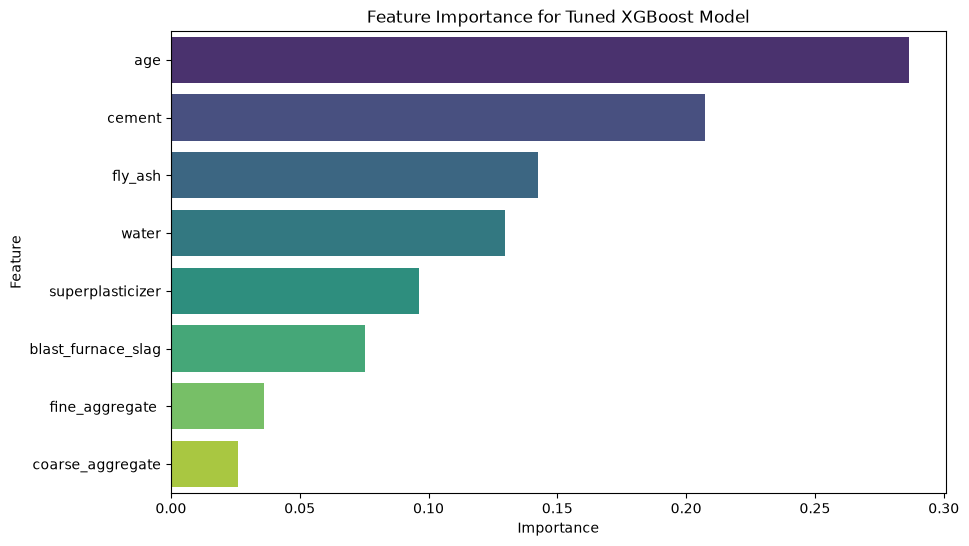

In [32]:
# Compare original model performance with tuned model performance
original_results = {
    'Model': 'Original',
    'R2': r2,
    'MSE': mse,
    'MAE': mae,
}

tuned_results = {
    'Model': 'Tuned',
    'R2': r2_score(Y_test, y_pred_tuned),
    'MSE': mean_squared_error(Y_test, y_pred_tuned),
    'MAE': mean_absolute_error(Y_test, y_pred_tuned),
}

comparison_df = pd.DataFrame([original_results, tuned_results]).set_index('Model')
print(comparison_df)

plt.figure(figsize=(8, 6))
plt.scatter(Y_test, y_pred_tuned, alpha=0.6, label='Tuned predictions')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], '--', color='red', linewidth=2, label='Perfect fit')
plt.xlabel('Actual Concrete Strength')
plt.ylabel('Predicted Concrete Strength')
plt.title('Actual vs Tuned Predicted Concrete Compressive Strength')
plt.legend()
plt.grid(True)
plt.show()

# Residual analysis for the tuned model
residuals = Y_test - y_pred_tuned
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_tuned, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Concrete Strength')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot for Tuned XGBoost Model')
plt.grid(True)
plt.show()

# Feature importance from the tuned XGBoost model
feature_importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print('Top feature importances:')
print(feature_importances)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance for Tuned XGBoost Model')
plt.show()

In [33]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score

# Baseline comparison against mean prediction
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, Y_train)
y_pred_baseline = baseline.predict(X_test)

baseline_mse = mean_squared_error(Y_test, y_pred_baseline)
baseline_rmse = np.sqrt(baseline_mse)
baseline_mae = mean_absolute_error(Y_test, y_pred_baseline)
baseline_r2 = r2_score(Y_test, y_pred_baseline)

baseline_results = {
    'Model': 'Baseline Mean',
    'R2': baseline_r2,
    'MSE': baseline_mse,
    'RMSE': baseline_rmse,
    'MAE': baseline_mae,
}
print(pd.DataFrame([baseline_results]).set_index('Model'))

# Cross-validation for the tuned model
cv_scores = cross_val_score(best_model, X_train, Y_train, cv=5, scoring='r2', n_jobs=-1)
print(f'5-fold CV R2 scores for tuned model: {cv_scores}')
print(f'CV R2 mean: {cv_scores.mean():.4f}, std: {cv_scores.std():.4f}')

comparison_df['RMSE'] = np.sqrt(comparison_df['MSE'])
print('\nComparison table with RMSE added:')
print(comparison_df)

                     R2         MSE       RMSE        MAE
Model                                                    
Baseline Mean -0.000737  267.155554  16.344894  13.188441
5-fold CV R2 scores for tuned model: [0.89440408 0.91843267 0.90522182 0.91798857 0.9076593 ]
CV R2 mean: 0.9087, std: 0.0089

Comparison table with RMSE added:
                R2        MSE       MAE      RMSE
Model                                            
Original  0.887073  30.146967  3.936155  5.490625
Tuned     0.888575  29.745887  3.700009  5.453979
